In [2]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [3]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from imports import *
from config import dir_config, main_config
from src.glm_hmm.cv_utils import bernoulli_null_loglik, pooled_bits_per_trial, select_best_n_states
from src.glm_hmm.experiments import CONFIGS


In [ ]:
processed_dir = Path(dir_config.data.processed)
glm_hmm_dir = processed_dir / "glm_hmm"

MODEL_PATHS = {f.stem: f for f in glm_hmm_dir.iterdir() if f.is_dir()}

In [ ]:
def session_bits(bundle):
    """Session-wise CV: bits/trial computed per session then averaged (mean, SEM across sessions)."""
    sw = bundle["session_wise"]
    states = np.array(list(sw["models"][0].keys()))
    n_trials, null = [], []
    for df in bundle["data"].values():
        valid = ~df["invalid_idx"].values
        y = df["choices"].values[valid]
        p = np.clip(y.mean(), 1e-6, 1 - 1e-6)
        n_trials.append(int(valid.sum()))
        null.append((y * np.log(p) + (1 - y) * np.log(1 - p)).sum())
    n_trials, null = np.array(n_trials), np.array(null)
    bits = (sw["test_ll"].sum(2) - null[:, None]) / (n_trials[:, None] * np.log(2))
    return states, bits.mean(0), bits.std(0) / np.sqrt(bits.shape[0])

def pooled_bits(bundle):
    """Pooled CV: (states, mean_bits, sem_bits) over one held-out pass, vs the Bernoulli null."""
    gpc = bundle["group_pooled_cv"]
    null_ll, n_valid = bernoulli_null_loglik(bundle["data"])
    mean_bits, sem_bits = pooled_bits_per_trial(gpc["test_ll"], gpc["n_test_trials"], null_ll, n_valid)
    return np.asarray(gpc["state_range"]), mean_bits, sem_bits

def parsimonious_k(states, mean_bits, sem_bits):
    """Smallest K within 1 SEM (or tol) of the peak; mirrors cv_utils.select_best_n_states."""
    best_idx = int(np.argmax(mean_bits))
    cutoff = mean_bits[best_idx] - sem_bits[best_idx]
    chosen_idx = next(i for i in range(best_idx + 1) if mean_bits[i] >= cutoff)
    return int(states[chosen_idx]), int(states[best_idx])

def plot_test_ll_bits(states, mean_bits, sem_bits, title="", ax=None, best_k=None):
    if ax is None:
        ax = plt.gca()

    ax.errorbar(states, mean_bits, yerr=sem_bits, marker="o", markersize=9, linewidth=2.5, capsize=4)

    if best_k is not None:
        # plot a box around the best K value
        best_idx = np.where(states == best_k)[0][0]
        ax.plot(states[best_idx], mean_bits[best_idx], marker="o", markersize=15, markerfacecolor="none", markeredgecolor="red", markeredgewidth=2)
    ax.axhline(0, color="black", linewidth=1, linestyle=":")  # Bernoulli (coin-flip) null
    ax.set_xlabel("Number of States", fontsize=20)
    ax.set_ylabel("Test LL (bits/trial)", fontsize=20)
    ax.tick_params(labelsize=15)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    xticks = states.astype(int)
    if xticks is not None:
        ax.set_xticks(xticks)
    ax.set_title(title, fontsize=20)


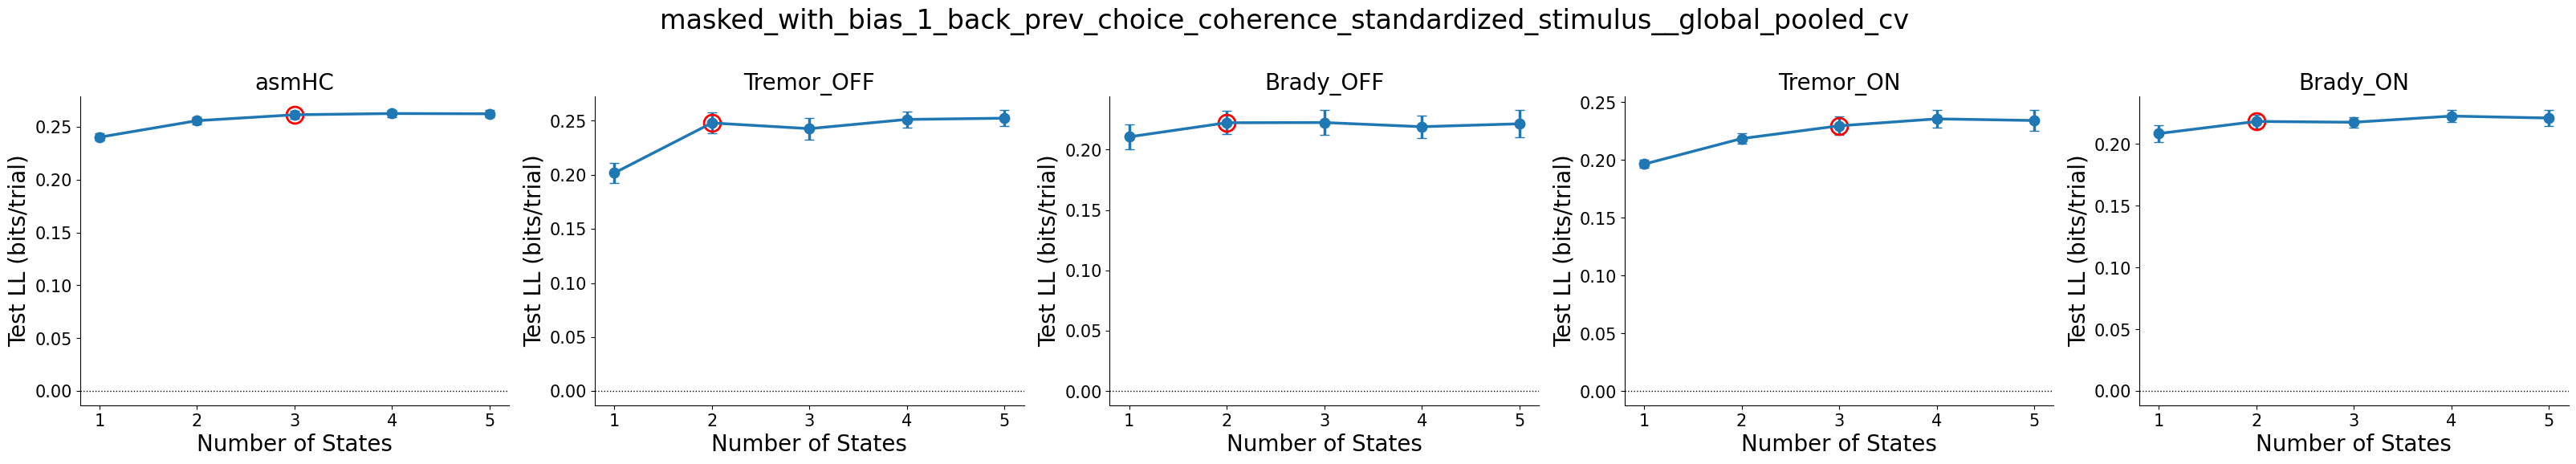

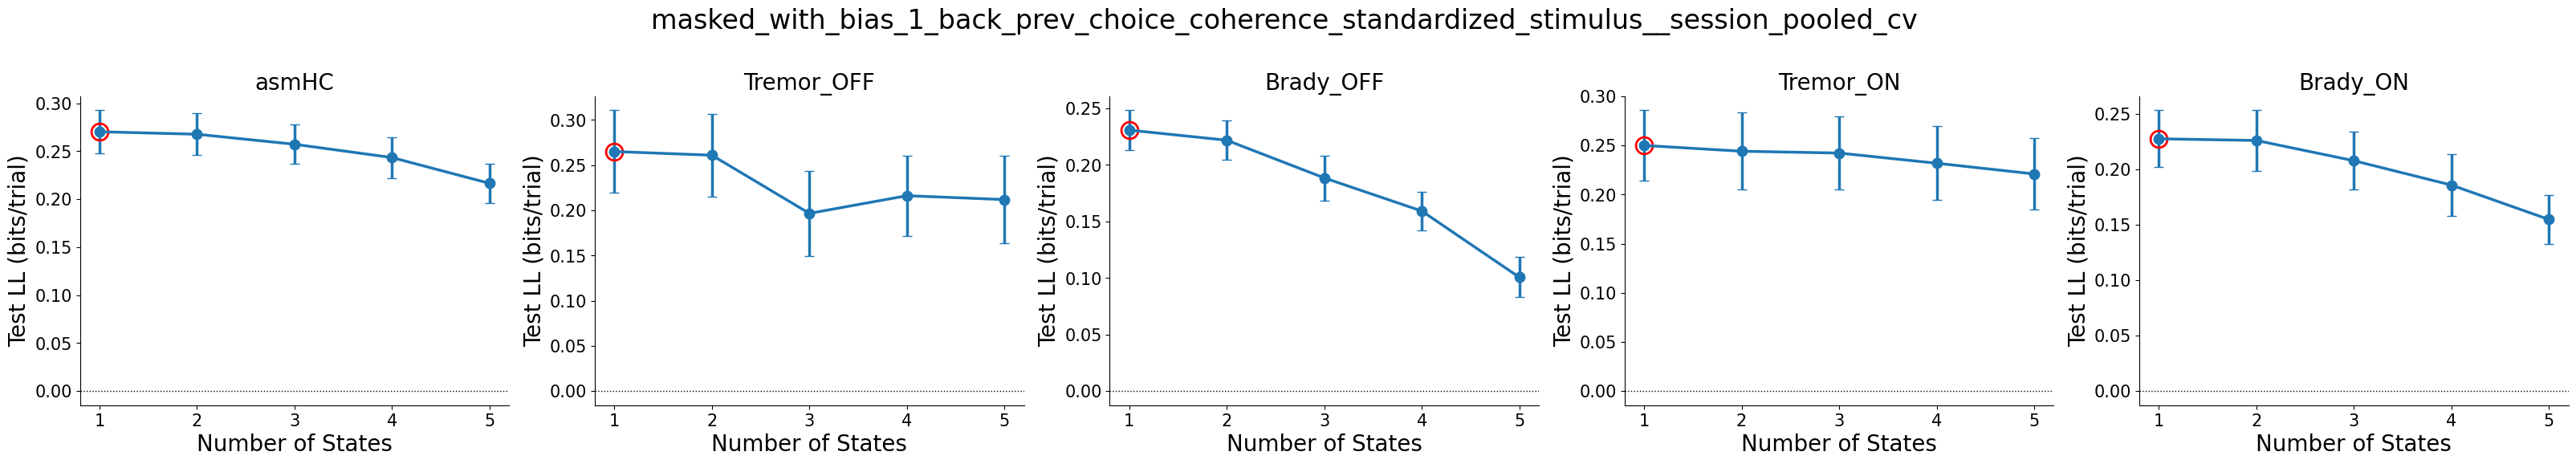

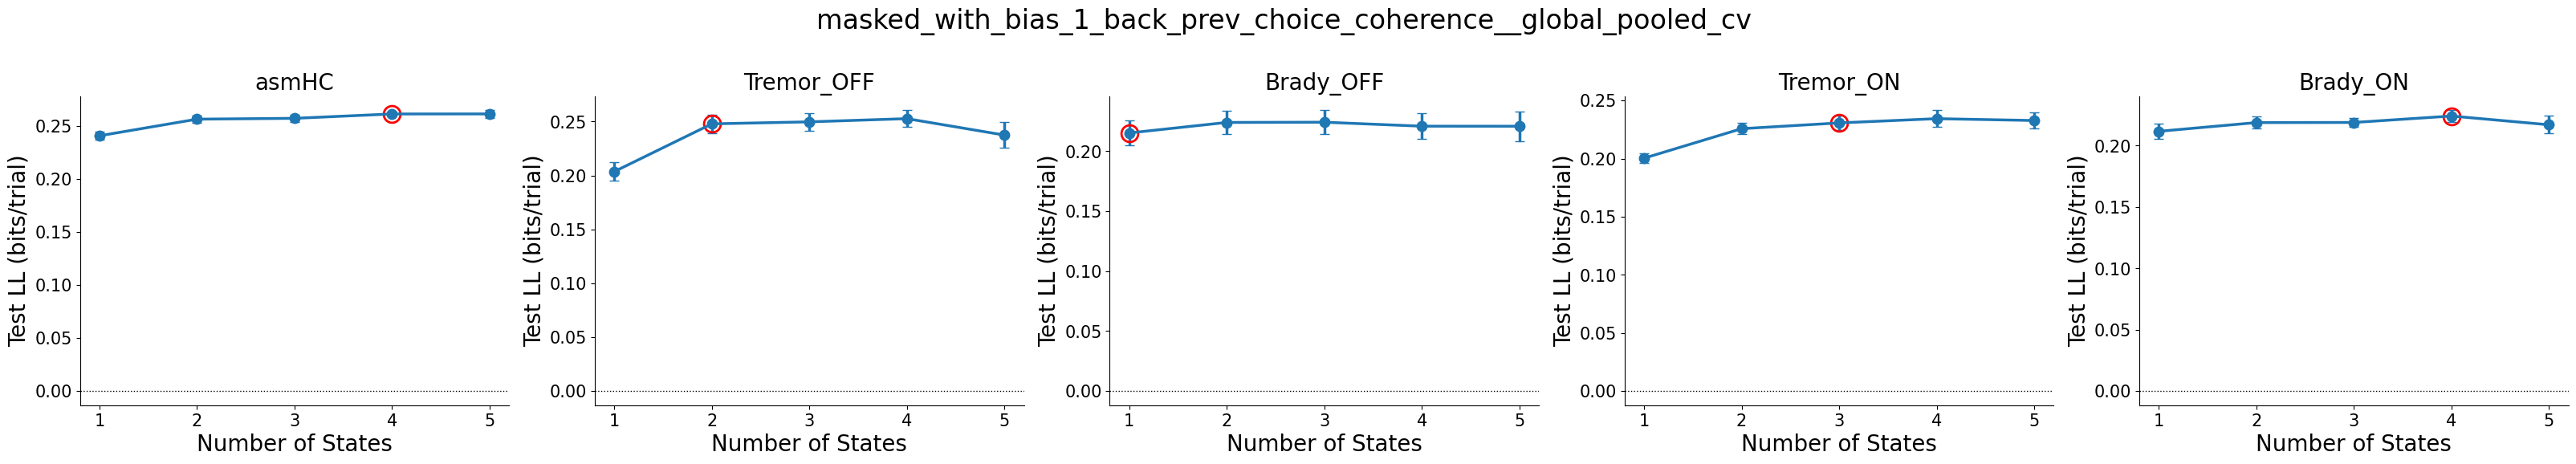

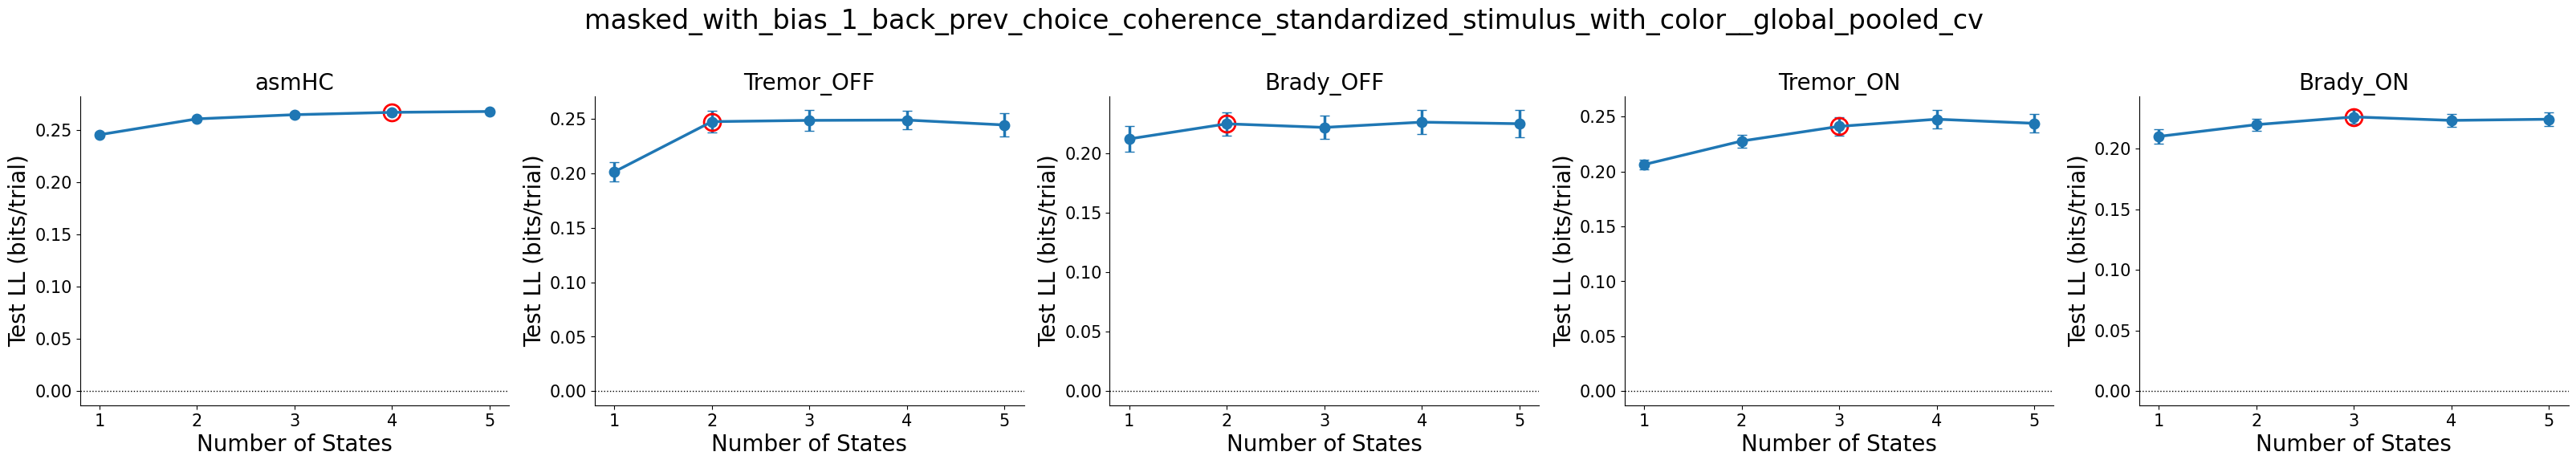

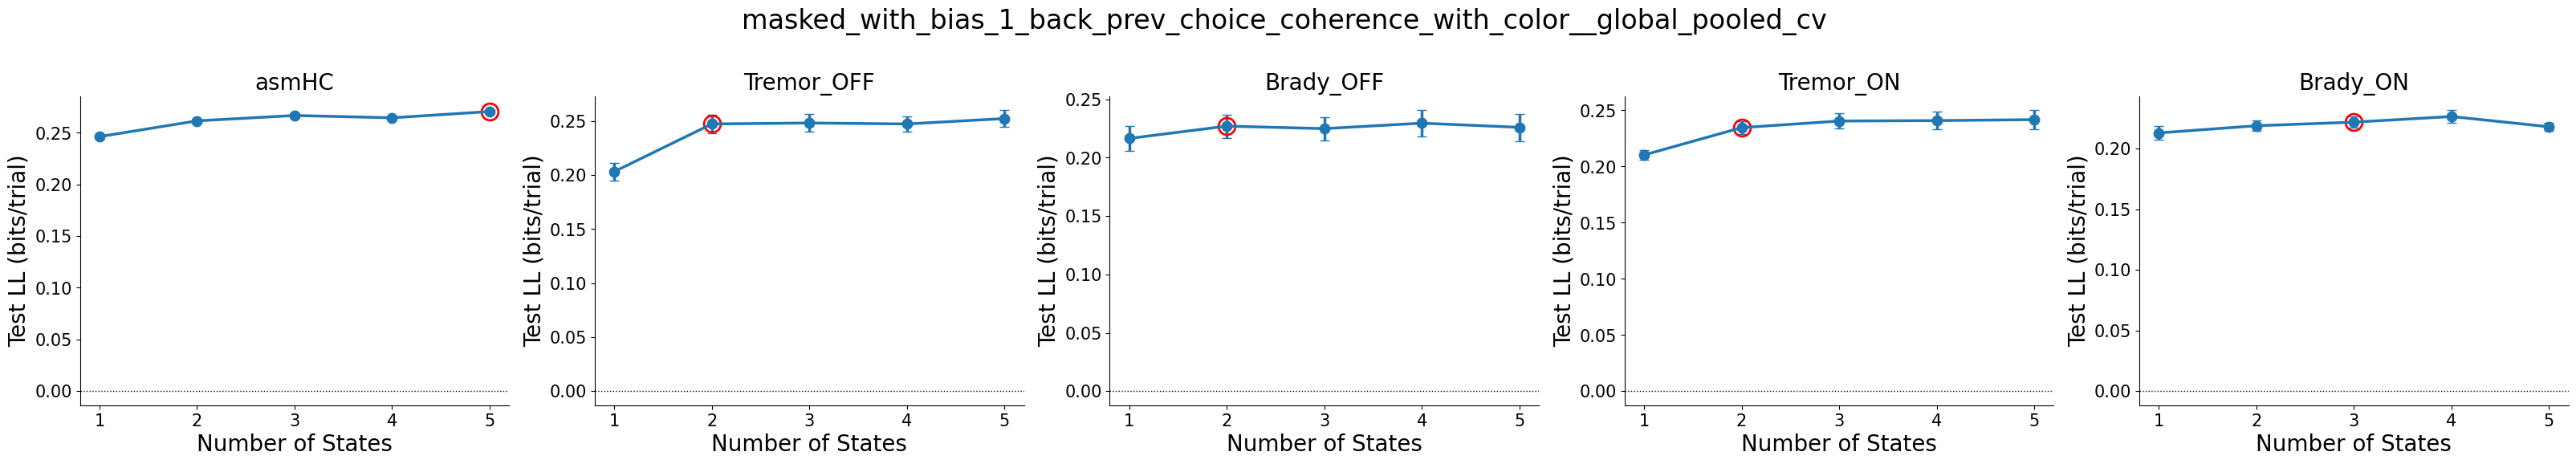

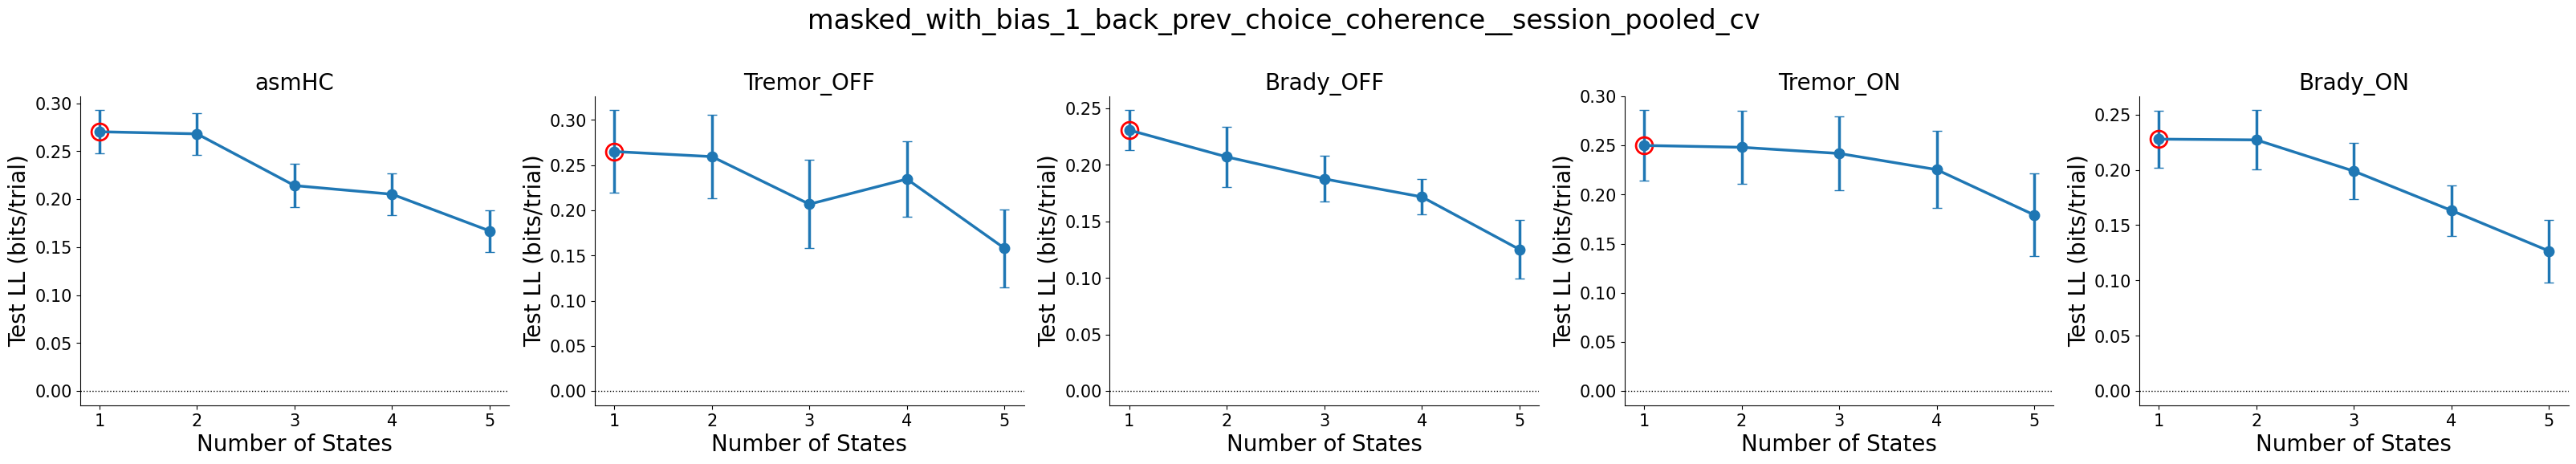

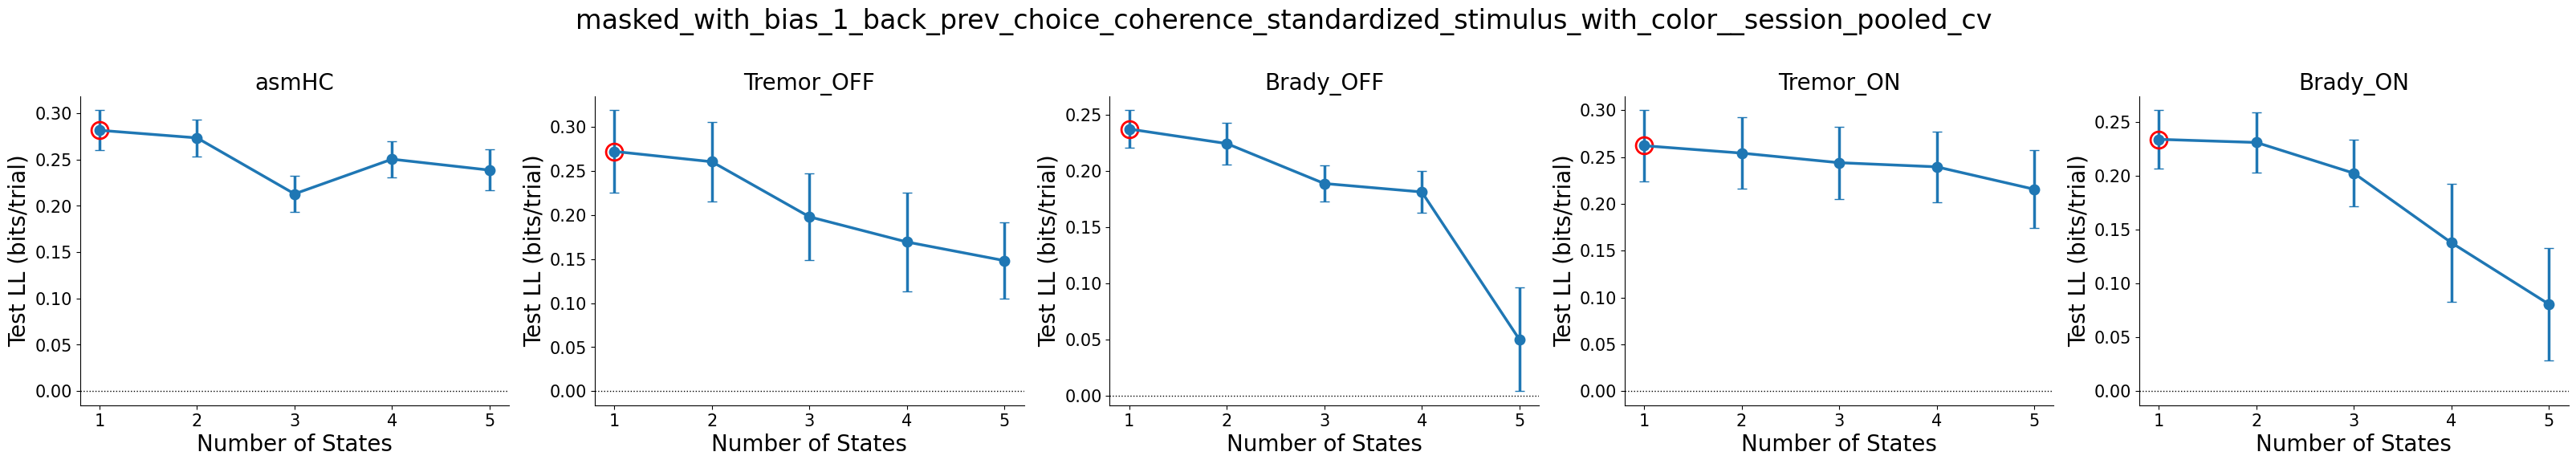

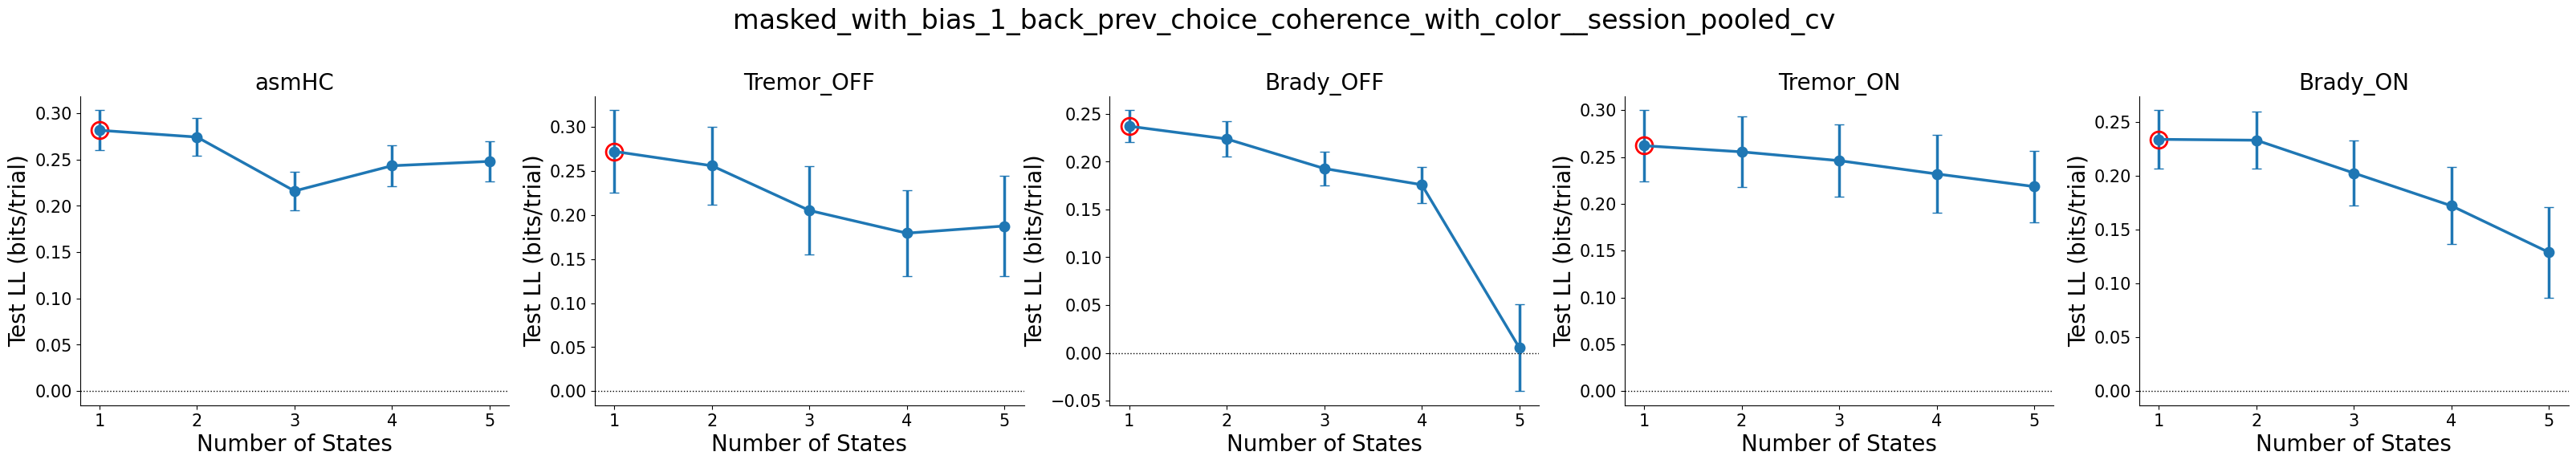

In [ ]:
desired_order = ["asmHC", "Tremor_OFF", "Brady_OFF", "Tremor_ON", "Brady_ON"]
order_map = {name: i for i, name in enumerate(desired_order)}

for model_name, model_path in MODEL_PATHS.items():

    cv_type = "pooled_cv" if model_name.endswith("__global_pooled_cv") else "session_cv"

    if cv_type == "pooled_cv":
        test_ll_fn = pooled_bits
    elif cv_type == "session_cv":
        test_ll_fn = session_bits

    fig, axs = plt.subplots(1, 5, figsize=(40, 5))
    groups = {}
    for i, subtype_model in enumerate(sorted(model_path.glob("*.pkl"), key=lambda p: order_map.get(p.stem, float("inf")))):
        group_name = subtype_model.stem
        with open(subtype_model, "rb") as f:
            groups[group_name] = pickle.load(f)

        states, mean_bits, sem_bits = test_ll_fn(groups[group_name])
        best_k, _ = parsimonious_k(states, mean_bits, sem_bits)

        groups[group_name]["best_k"] = best_k

        with open(subtype_model, "wb") as f:
            pickle.dump(groups[group_name], f)


        plot_test_ll_bits(states, mean_bits, sem_bits, title=f"{group_name}", ax=axs[i], best_k=best_k)

    fig.suptitle(f"{model_name}", fontsize=24, y=1.1)
    fig.savefig(model_path / "model_selection.png", bbox_inches="tight")
